# EXAMEN PRÁCTICO II

## Predicción del riesgo académico mediante Machine Learning

## 1. Importación de librerías

In [1]:
# ============================================
# 1. Importación de librerías
# ============================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Ignorar advertencias
import warnings
warnings.filterwarnings("ignore")

## 2. Lectura de datos

In [2]:
# ============================================
# 2. Lectura de datos
# ============================================

# Cargar datasets
df_academico = pd.read_csv("dataset_academico.csv")
df_psicosocial = pd.read_csv("dataset_psicosocial.csv")

print("Dataset Académico")
display(df_academico.head())

print("Dataset Psicosocial")
display(df_psicosocial.head())



Dataset Académico


,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,tendencia_notas,participacion_clase,entrega_tareas,repitio_grado,horas_estudio_semanal,target
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,1,Empeorando,Media,64.4,1,3.9,Continua_estudiando
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,0,Mejorando,Media,100.0,0,12.8,Continua_estudiando
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,2,Estable,Alta,77.5,0,13.8,Continua_estudiando
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,5,NaN,Alta,73.1,1,16.1,Continua_estudiando
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,2,Estable,Media,92.9,0,12.9,Continua_estudiando


Dataset Psicosocial


,id_estudiante,genero,estructura_familiar,num_hermanos,nivel_socioeconomico,nivel_educativo_padres,trabaja_estudiante,horas_trabajo_semanal,acceso_internet_hogar,distancia_colegio_km,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,2467,Femenino,Un solo padre,3,Medio,Superior,0,NaN,1,6.61,4.0,3,4,3,0,Regular,7.4,0,0,0
1,3555,Masculino,Ambos padres,2,Medio,Superior,0,NaN,0,0.87,NaN,3,4,2,0,Regular,8.3,0,0,0
2,3064,Masculino,Ambos padres,0,Alto,Secundaria,0,NaN,1,0.28,3.0,3,1,5,0,Buena,5.6,0,1,0
3,1189,Femenino,Otros familiares,3,Medio-bajo,Secundaria,1,16.2,1,4.02,3.0,3,3,3,0,Regular,6.9,0,0,0
4,3779,Masculino,Ambos padres,0,Medio,Superior,0,NaN,1,3.51,5.0,3,4,4,0,Buena,7.5,1,0,0


In [3]:
#Verificamos sus dimensiones.
print("Dimensiones del dataset académico:", df_academico.shape)
print("Dimensiones del dataset psicosocial:", df_psicosocial.shape)

Dimensiones del dataset académico: (3000, 17)
Dimensiones del dataset psicosocial: (3000, 20)


In [4]:
#Verificamos los tipos de datos.
print("Información del dataset académico")
df_academico.info()

print("\nInformación del dataset psicosocial")
df_psicosocial.info()

Información del dataset académico
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_estudiante                     3000 non-null   int64  
 1   edad                              3000 non-null   float64
 2   grado                             3000 non-null   int64  
 3   promedio_matematica               3000 non-null   float64
 4   promedio_comunicacion             3000 non-null   float64
 5   promedio_ciencias                 2910 non-null   float64
 6   promedio_general                  3000 non-null   float64
 7   num_cursos_desaprobados           3000 non-null   int64  
 8   porcentaje_asistencia             2940 non-null   float64
 9   num_tardanzas                     3000 non-null   int64  
 10  num_inasistencias_injustificadas  3000 non-null   int64  
 11  tendencia_notas                   2880 non-nul

## 3. Integración de datasets

In [5]:
# ============================================
# 3. Integración de datasets
# ============================================

# Unir los datasets mediante el identificador del estudiante
df = pd.merge(
    df_academico,
    df_psicosocial,
    on="id_estudiante",
    how="inner"
)

print("Integración realizada correctamente.")

#Verificar dimensiones del dataset integrado

print("Dimensiones del dataset académico:", df_academico.shape)
print("Dimensiones del dataset psicosocial:", df_psicosocial.shape)
print("Dimensiones del dataset integrado:", df.shape)

Integración realizada correctamente.
Dimensiones del dataset académico: (3000, 17)
Dimensiones del dataset psicosocial: (3000, 20)
Dimensiones del dataset integrado: (3000, 36)


In [6]:
#Verificar las primeras filas
df.head()

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


In [7]:
#Comprobar que no existan IDs duplicados
duplicados = df["id_estudiante"].duplicated().sum()

print(f"IDs duplicados: {duplicados}")

IDs duplicados: 0


In [8]:
#Guardar el dataset integrado
df.to_csv("dataset_unido.csv", index=False)

print("Dataset integrado guardado correctamente.")

Dataset integrado guardado correctamente.


## 4. Análisis exploratorio de datos

In [9]:
#Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10  num_inasistencias_injustificadas         3000 non-null   in

In [10]:
#Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_estudiante,3000.0,2500.500000,866.169729,1001.00,1750.7500,2500.500,3250.2500,4000.00
edad,3000.0,14.462667,1.550723,6.00,13.0000,14.000,16.0000,30.00
grado,3000.0,2.958333,1.412774,1.00,2.0000,3.000,4.0000,5.00
promedio_matematica,3000.0,12.209660,4.058927,0.00,9.2375,12.240,15.2125,20.00
promedio_comunicacion,3000.0,12.295623,4.087180,0.00,9.4000,12.355,15.4000,20.00
promedio_ciencias,2910.0,12.389969,4.126823,0.00,9.4800,12.490,15.5200,20.00
promedio_general,3000.0,12.312043,3.605354,2.14,9.6175,12.395,15.1600,20.00
num_cursos_desaprobados,3000.0,1.882000,1.768932,0.00,0.0000,2.000,3.0000,9.00
porcentaje_asistencia,2940.0,78.370748,12.408769,31.60,69.9000,78.700,87.7250,112.70
num_tardanzas,3000.0,4.870000,3.554431,0.00,2.0000,4.000,7.0000,57.00


In [11]:
#Tipos de datos
df.dtypes.value_counts()

int64      16
float64    12
str         8
Name: count, dtype: int64

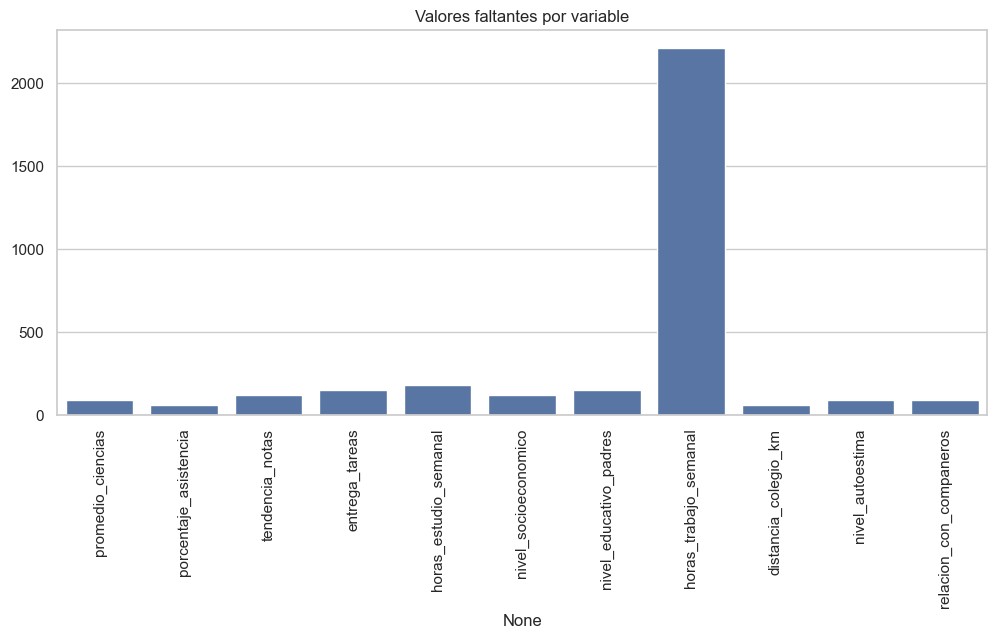

In [12]:
#Valores faltantes
faltantes = df.isnull().sum()

faltantes = faltantes[faltantes > 0]

faltantes.sort_values(ascending=False)

#Grafico

plt.figure(figsize=(12,5))

sns.barplot(
    x=faltantes.index,
    y=faltantes.values
)

plt.xticks(rotation=90)
plt.title("Valores faltantes por variable")

plt.show()

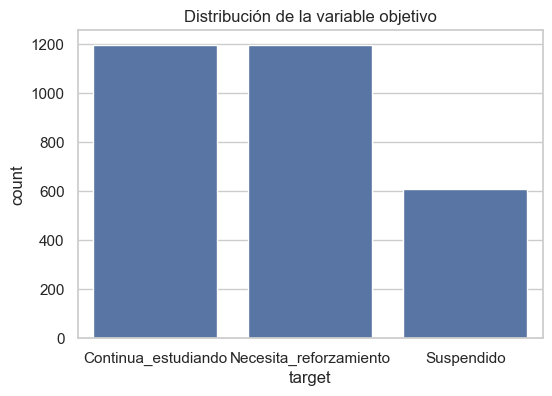

In [14]:
#Distribución del Target

df["target"].value_counts()

#Grafico de distribución del Target

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Distribución de la variable objetivo")

plt.show()

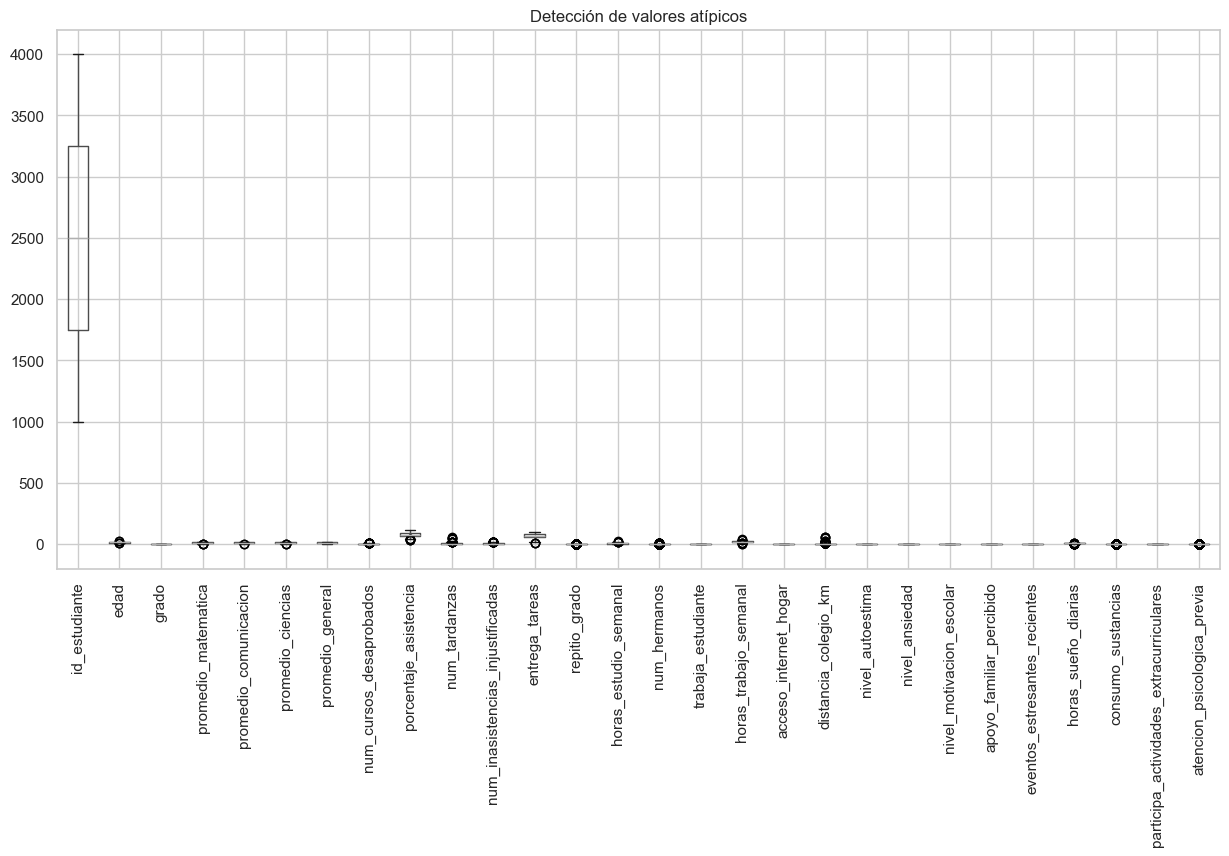

In [71]:
#Outliders
numericas = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(15,7))
df[numericas].boxplot(rot=90)
plt.title("Detección de valores atípicos")
plt.show()

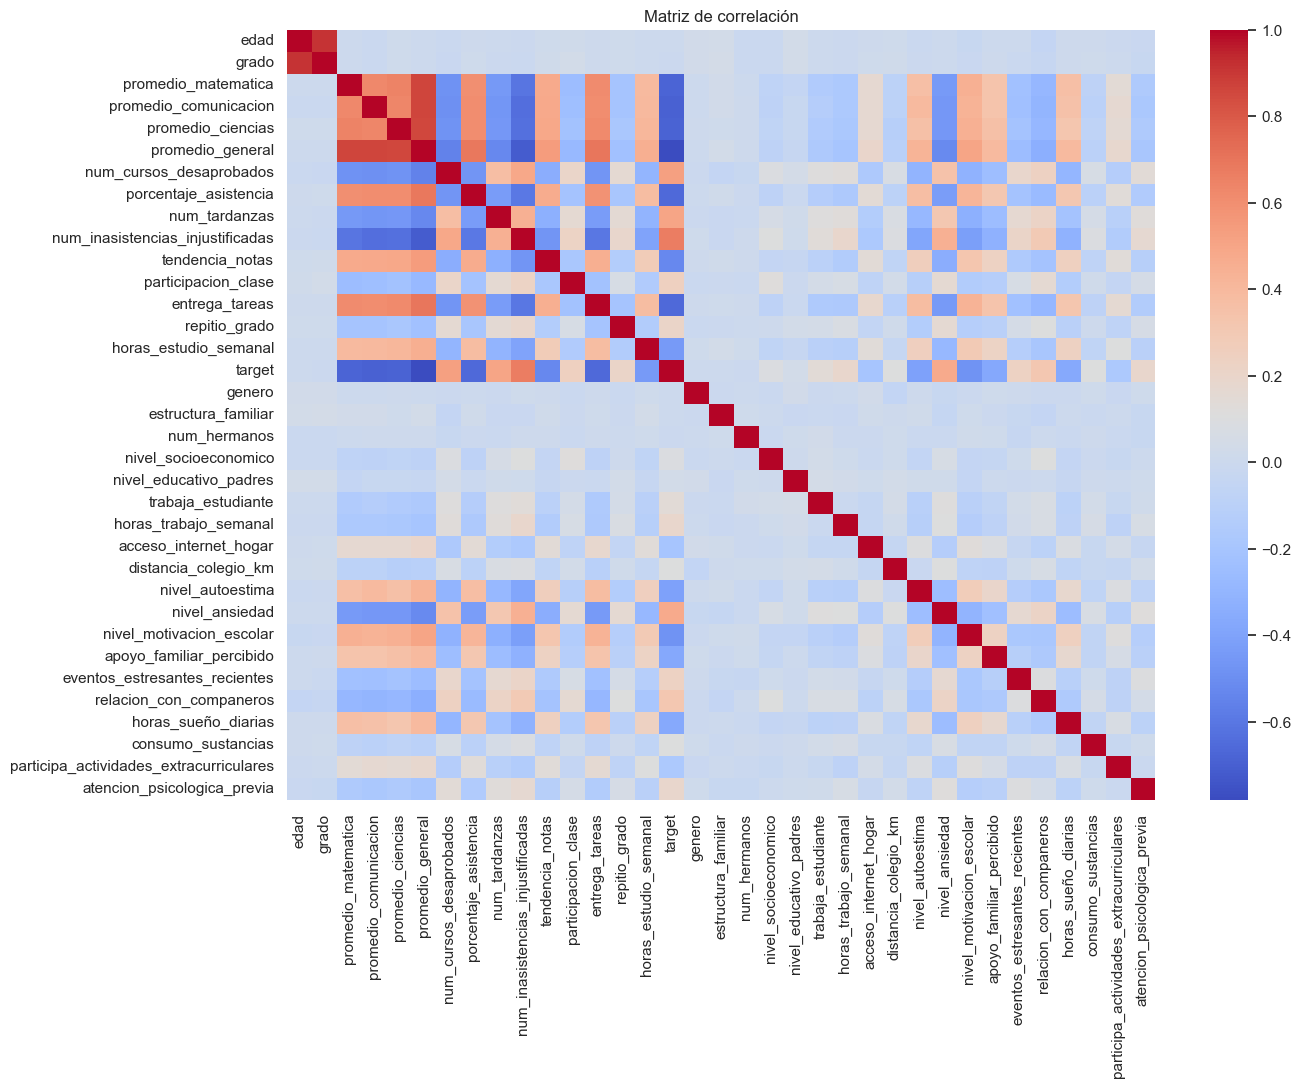

In [72]:
#Matriz de correlación
plt.figure(figsize=(14,10))
sns.heatmap(df_pre.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()

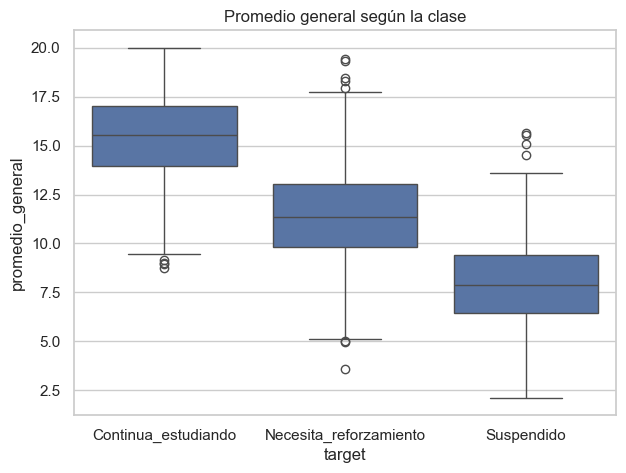

In [73]:
#Promedio general según la clase
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="target", y="promedio_general")
plt.title("Promedio general según la clase")
plt.show()

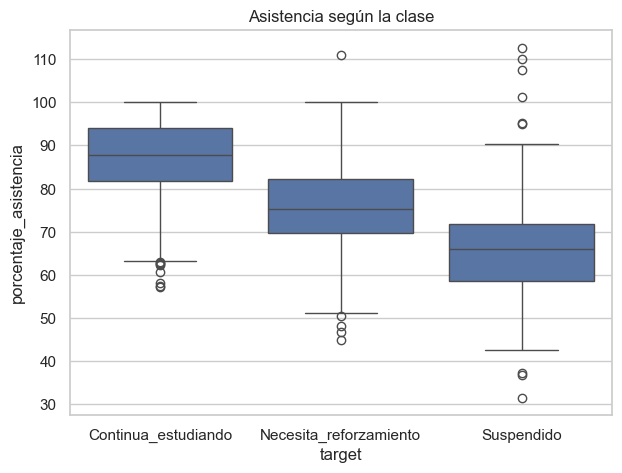

In [74]:
#Asistencia según la clase
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="target", y="porcentaje_asistencia")
plt.title("Asistencia según la clase")
plt.show()

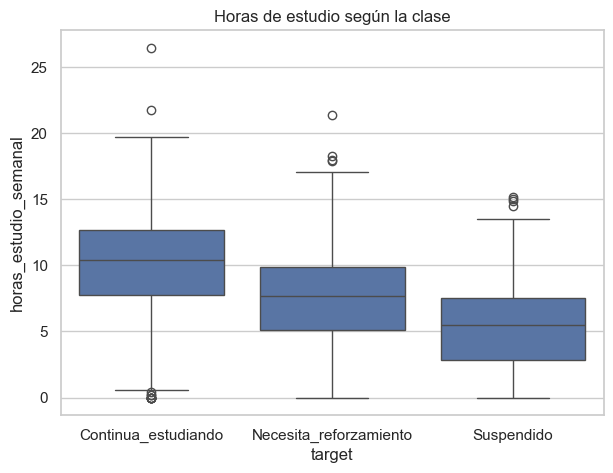

In [75]:
#Horas de estudio según la clase
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="target", y="horas_estudio_semanal")
plt.title("Horas de estudio según la clase")
plt.show()

In [15]:
#Variables categóricas

df.select_dtypes(include="object").columns

Index(['tendencia_notas', 'participacion_clase', 'target', 'genero',
       'estructura_familiar', 'nivel_socioeconomico', 'nivel_educativo_padres',
       'relacion_con_companeros'],
      dtype='str')

In [16]:
#Variables numéricas

df.select_dtypes(include=["int64","float64"]).columns

Index(['id_estudiante', 'edad', 'grado', 'promedio_matematica',
       'promedio_comunicacion', 'promedio_ciencias', 'promedio_general',
       'num_cursos_desaprobados', 'porcentaje_asistencia', 'num_tardanzas',
       'num_inasistencias_injustificadas', 'entrega_tareas', 'repitio_grado',
       'horas_estudio_semanal', 'num_hermanos', 'trabaja_estudiante',
       'horas_trabajo_semanal', 'acceso_internet_hogar',
       'distancia_colegio_km', 'nivel_autoestima', 'nivel_ansiedad',
       'nivel_motivacion_escolar', 'apoyo_familiar_percibido',
       'eventos_estresantes_recientes', 'horas_sueño_diarias',
       'consumo_sustancias', 'participa_actividades_extracurriculares',
       'atencion_psicologica_previa'],
      dtype='str')

## 5. Preprocesamiento

In [17]:
#Copia del dataset

# ============================================
# 5. Preprocesamiento
# ============================================

df_pre = df.copy()

In [26]:
#Valores faltantes
df_pre.isnull().sum().sort_values(ascending=False)

horas_trabajo_semanal                      2210
horas_estudio_semanal                       180
entrega_tareas                              150
nivel_autoestima                             90
promedio_ciencias                            90
porcentaje_asistencia                        60
distancia_colegio_km                         60
promedio_matematica                           0
grado                                         0
edad                                          0
num_cursos_desaprobados                       0
tendencia_notas                               0
num_inasistencias_injustificadas              0
participacion_clase                           0
repitio_grado                                 0
target                                        0
num_tardanzas                                 0
promedio_general                              0
promedio_comunicacion                         0
num_hermanos                                  0
estructura_familiar                     

In [27]:
# Variables numéricas
columnas_numericas = df_pre.select_dtypes(include=["int64", "float64"]).columns

for columna in columnas_numericas:
    df_pre[columna] = df_pre[columna].fillna(df_pre[columna].median())

In [28]:
# Variables categóricas
columnas_categoricas = df_pre.select_dtypes(include="object").columns

for columna in columnas_categoricas:
    df_pre[columna] = df_pre[columna].fillna(df_pre[columna].mode()[0])

In [30]:
#Verificar que ya no existan nulos
df_pre.isnull().sum().sum()

np.int64(0)

In [33]:
df_pre["trabaja_estudiante"].value_counts()

trabaja_estudiante
0    2210
1     790
Name: count, dtype: int64

In [34]:
df_pre.groupby("trabaja_estudiante")["horas_trabajo_semanal"].describe()

,count,mean,std,min,25%,50%,75%,max
trabaja_estudiante,,,,,,,,
0,2210.0,20.800000,0.000000,20.8,20.8,20.8,20.8,20.8
1,790.0,20.743165,5.340965,2.0,17.4,20.8,24.2,39.2


In [35]:
df_pre["horas_trabajo_semanal"] = df_pre["horas_trabajo_semanal"].fillna(0)

In [36]:
df_pre.isnull().sum().sort_values(ascending=False).head(10)

edad                                0
grado                               0
promedio_matematica                 0
promedio_comunicacion               0
promedio_ciencias                   0
promedio_general                    0
num_cursos_desaprobados             0
porcentaje_asistencia               0
num_tardanzas                       0
num_inasistencias_injustificadas    0
dtype: int64

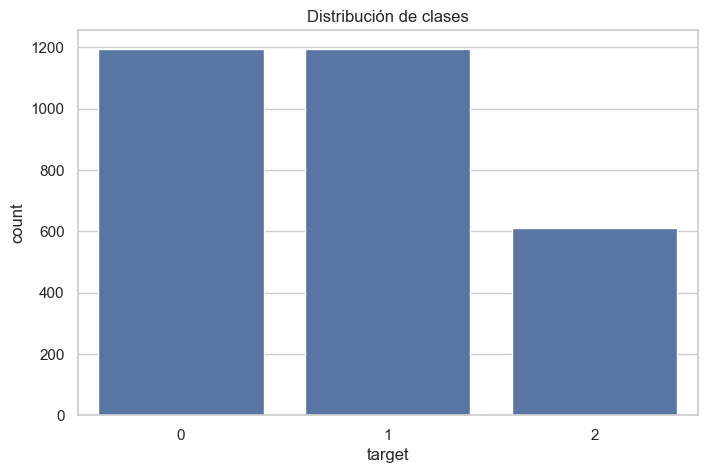

In [70]:
y.value_counts()

sns.countplot(x=y)
plt.title("Distribución de clases")
plt.show()


In [46]:
#Eliminar ID
if "id_estudiante" in df_pre.columns:
    df_pre.drop("id_estudiante", axis=1, inplace=True)
    print("Columna 'id_estudiante' eliminada.")
else:
    print("La columna 'id_estudiante' ya había sido eliminada.")

La columna 'id_estudiante' ya había sido eliminada.


In [38]:
#Codificación de variables categóricas
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for columna in df_pre.select_dtypes(include="object").columns:
    df_pre[columna] = label_encoder.fit_transform(df_pre[columna])

In [39]:
#Verificar tipos de datos
df_pre.dtypes.value_counts()

int64      23
float64    12
Name: count, dtype: int64

In [40]:
#Separar variables predictoras y objetivo
X = df_pre.drop("target", axis=1)
y = df_pre["target"]

In [41]:
#Guardar dataset preprocesado
df_pre.to_csv("dataset_preprocesado.csv", index=False)

print("Dataset preprocesado guardado correctamente.")

Dataset preprocesado guardado correctamente.


## 6. División de datos

In [42]:
# ============================================
# 6. División de datos
# ============================================

X = df_pre.drop("target", axis=1)
y = df_pre["target"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (3000, 34)
Variable objetivo: (3000,)


In [43]:
#Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [44]:
#Verificar dimensiones
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2400, 34)
X_test : (600, 34)
y_train: (2400,)
y_test : (600,)


In [45]:
#Escalado para SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Entrenamiento de modelos

In [47]:
# ============================================
# 7.1 Decision Tree
# ============================================

modelo_dt = DecisionTreeClassifier(
    random_state=42
)

modelo_dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Accuracy: 0.6733333333333333
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       239
           1       0.61      0.58      0.59       239
           2       0.61      0.68      0.64       122

    accuracy                           0.67       600
   macro avg       0.66      0.67      0.67       600
weighted avg       0.67      0.67      0.67       600



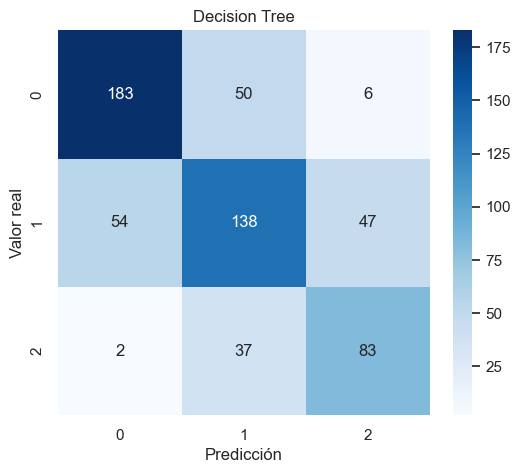

In [56]:
#Predicción
y_pred_dt = modelo_dt.predict(X_test)
#Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
#Reporte
print(classification_report(y_test, y_pred_dt))
#Matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [62]:
y_train_pred = modelo_dt.predict(X_train)
y_test_pred = modelo_dt.predict(X_test)

print("Train:", accuracy_score(y_train, y_train_pred))
print("Test :", accuracy_score(y_test, y_test_pred))

Train: 1.0
Test : 0.6733333333333333


In [52]:
# ============================================
# 7.2 Random Forest
# ============================================

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       239
           1       0.72      0.76      0.74       239
           2       0.73      0.76      0.75       122

    accuracy                           0.78       600
   macro avg       0.78      0.78      0.78       600
weighted avg       0.79      0.78      0.79       600



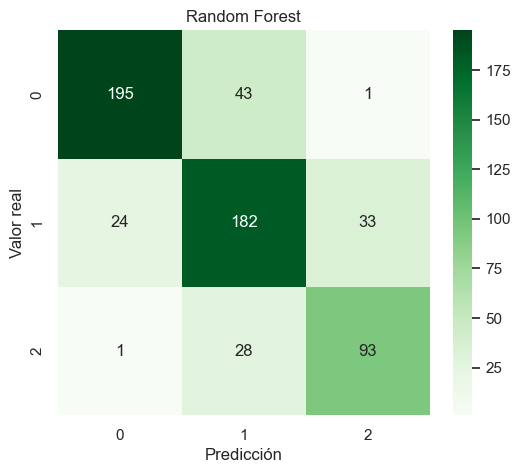

In [53]:
#Predicción
y_pred_rf = modelo_rf.predict(X_test)
#Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
#Reporte
print(classification_report(y_test, y_pred_rf))
#Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [63]:
y_train_pred = modelo_rf.predict(X_train)
y_test_pred = modelo_rf.predict(X_test)

print("Train:", accuracy_score(y_train, y_train_pred))
print("Test :", accuracy_score(y_test, y_test_pred))

Train: 1.0
Test : 0.7833333333333333


In [54]:
# ============================================
# 7.3 SVM
# ============================================

modelo_svm = SVC(
    kernel="rbf",
    random_state=42
)

modelo_svm.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       239
           1       0.69      0.77      0.73       239
           2       0.74      0.70      0.72       122

    accuracy                           0.77       600
   macro avg       0.77      0.76      0.76       600
weighted avg       0.78      0.77      0.77       600



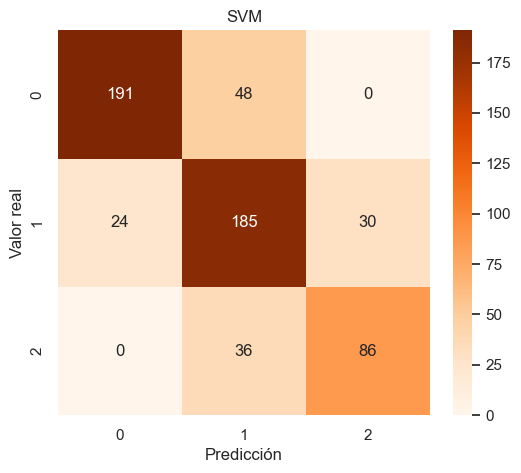

In [55]:
#Predicción
y_pred_svm = modelo_svm.predict(
    X_test_scaled
)
#Accuracy
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy:", accuracy_svm)

#Reporte
print(classification_report(
    y_test,
    y_pred_svm
))
#Matriz de confusión
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [64]:
y_train_pred = modelo_svm.predict(X_train)
y_test_pred = modelo_svm.predict(X_test)

print("Train:", accuracy_score(y_train, y_train_pred))
print("Test :", accuracy_score(y_test, y_test_pred))

Train: 0.39875
Test : 0.3983333333333333


In [65]:
#Validación cruzada (Cross Validation)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Accuracy por fold:", scores)
print("Accuracy promedio:", scores.mean())
print("Desviación estándar:", scores.std())

Accuracy por fold: [0.77833333 0.78166667 0.785      0.78333333 0.76333333]
Accuracy promedio: 0.7783333333333333
Desviación estándar: 0.007817359599705725


## 8. Evaluación de modelos

In [57]:
# ============================================
# 8. Comparación de resultados
# ============================================

resultados = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.673333,0.673404,0.673333,0.672767
1,Random Forest,0.783333,0.788514,0.783333,0.785043
2,SVM,0.770000,0.778562,0.770000,0.772233


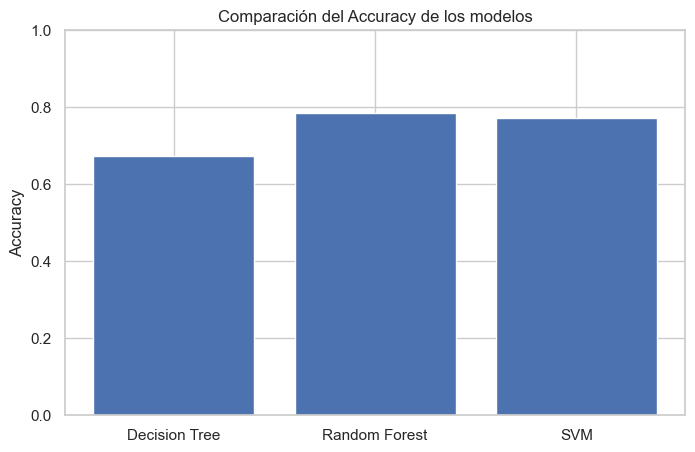

In [58]:
#Grafico de comparación de Accuracy
plt.figure(figsize=(8,5))

plt.bar(resultados["Modelo"], resultados["Accuracy"])

plt.title("Comparación del Accuracy de los modelos")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

## 9. Conclusiones

Conclusión 1

Se desarrollaron y evaluaron tres modelos de clasificación multiclase (Decision Tree, Random Forest y SVM) para predecir la situación académica de los estudiantes utilizando información académica y psicosocial.

Conclusión 2

El modelo Random Forest obtuvo el mejor desempeño general, alcanzando un Accuracy aproximado del 78.33 %, además de presentar los mayores valores de Precision, Recall y F1-Score entre los modelos evaluados.

Conclusión 3

El modelo SVM mostró un rendimiento competitivo con un Accuracy del 77 %, siendo ligeramente inferior al de Random Forest, mientras que el Árbol de Decisión obtuvo el menor desempeño con un Accuracy cercano al 67 %.

Conclusión 4

Los resultados evidencian que la combinación de variables académicas y psicosociales permite construir modelos capaces de identificar el riesgo académico de los estudiantes, siendo Random Forest la alternativa más adecuada para este conjunto de datos.